In [62]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/big-five-personality-test/IPIP-FFM-data-8Nov2018/codebook.txt
/kaggle/input/big-five-personality-test/IPIP-FFM-data-8Nov2018/data-final.csv
/kaggle/input/big-five-personality-test/IPIP-FFM-data-8Nov2018/.directory


In [63]:
import pandas as pd

In [64]:
import numpy as np

In [65]:
data = pd.read_csv('/kaggle/input/big-five-personality-test/IPIP-FFM-data-8Nov2018/data-final.csv', sep='\t')
data

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,...,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,...,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015336,4.0,2.0,4.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,...,2018-11-08 12:04:58,1920.0,1080.0,3.0,160.0,10,2,US,39.9883,-75.2208
1015337,4.0,3.0,4.0,3.0,3.0,3.0,4.0,4.0,3.0,3.0,...,2018-11-08 12:07:18,1920.0,1080.0,3.0,122.0,7,1,US,38.0,-97.0
1015338,4.0,2.0,4.0,3.0,5.0,1.0,4.0,2.0,4.0,4.0,...,2018-11-08 12:07:49,1920.0,1080.0,2.0,135.0,12,6,US,36.1473,-86.777
1015339,2.0,4.0,3.0,4.0,2.0,2.0,1.0,4.0,2.0,4.0,...,2018-11-08 12:08:34,1920.0,1080.0,6.0,212.0,8,1,US,34.1067,-117.8067


In [66]:
data.head()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,...,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,...,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0


In [67]:
data.isnull().sum()

EXT1                     1783
EXT2                     1783
EXT3                     1783
EXT4                     1783
EXT5                     1783
                         ... 
endelapse                   0
IPC                         0
country                    77
lat_appx_lots_of_err        0
long_appx_lots_of_err       0
Length: 110, dtype: int64

In [68]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015341 entries, 0 to 1015340
Columns: 110 entries, EXT1 to long_appx_lots_of_err
dtypes: float64(104), int64(2), object(4)
memory usage: 852.1+ MB


In [69]:
data.describe()

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,OPN7_E,OPN8_E,OPN9_E,OPN10_E,screenw,screenh,introelapse,testelapse,endelapse,IPC
count,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,...,1.013558e+06,1.013558e+06,1.013558e+06,1.013558e+06,1.013275e+06,1.013275e+06,1.013275e+06,1.013558e+06,1.015341e+06,1.015341e+06
mean,2.648067e+00,2.773115e+00,3.288349e+00,3.140595e+00,3.276960e+00,2.401100e+00,2.771744e+00,3.414818e+00,2.963740e+00,3.556469e+00,...,7.689488e+03,5.423945e+03,6.325802e+03,5.336311e+03,1.149510e+03,8.262611e+02,9.590748e+02,6.754233e+02,2.701410e+03,1.045211e+01
std,1.264407e+00,1.323943e+00,1.215006e+00,1.237442e+00,1.277593e+00,1.225721e+00,1.400336e+00,1.271915e+00,1.346040e+00,1.305232e+00,...,5.841987e+05,2.629748e+05,4.298906e+05,4.408225e+05,5.600884e+02,1.802490e+02,5.104005e+04,2.017864e+04,1.483898e+06,3.982879e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-6.181300e+04,-5.001200e+04,-9.598600e+04,-3.594871e+06,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,...,2.279000e+03,2.144000e+03,2.329000e+03,1.484000e+03,4.140000e+02,7.200000e+02,5.000000e+00,1.710000e+02,9.000000e+00,1.000000e+00
50%,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,3.000000e+00,4.000000e+00,...,3.208000e+03,3.051000e+03,3.269000e+03,2.192000e+03,1.366000e+03,7.680000e+02,1.000000e+01,2.240000e+02,1.300000e+01,1.000000e+00
75%,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,5.000000e+00,...,4.729000e+03,4.469000e+03,4.785000e+03,3.362000e+03,1.440000e+03,9.000000e+02,3.000000e+01,3.130000e+02,1.800000e+01,2.000000e+00
max,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,...,3.891434e+08,1.696693e+08,3.470326e+08,3.344289e+08,1.366000e+04,8.802000e+03,2.944307e+07,1.189272e+07,1.493327e+09,7.250000e+02


In [70]:
personality_features = ['EXT', 'EST', 'AGR', 'CSN', 'OPN']

In [71]:
for traits in  personality_features:
    cols = [col for col in data.columns if col.startswith(traits) and len(col) == 4]
    data[traits + '_score'] = data[cols].mean(axis=1)

In [72]:
data = data.dropna(subset=[traits + '_score' for traits in personality_features])

In [73]:
X = data[[traits + '_score' for traits in personality_features]]

In [74]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [75]:
scaler = StandardScaler()

In [76]:
X_scaled = scaler.fit_transform(X)

In [77]:
kmeans = KMeans(n_clusters=5, random_state=42)

In [78]:
data['personality_cluster'] = kmeans.fit_predict(X_scaled)

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/tmp/ipykernel_24/3014737375.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['personality_cluster'] = kmeans.fit_predict(X_scaled)


In [79]:
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=[traits + '_score' for traits in personality_features]
)

In [80]:
print("Cluster Centers (Personality Profiles):")
print(cluster_centers)
print("\
Cluster Sizes:")
print(data['personality_cluster'].value_counts())

Cluster Centers (Personality Profiles):
   EXT_score  EST_score  AGR_score  CSN_score  OPN_score
0   0.422257   0.362737   0.394743   0.374052   0.328744
1   3.248776   3.518790   3.416845   3.364021   3.307647
2   2.617071   3.449274   3.059416   3.166288   3.323184
3   2.919035   2.940087   3.005313   2.801157   2.779154
4   3.101038   2.449193   3.011021   3.000146   3.341204
Cluster Sizes:
personality_cluster
4    289511
2    249551
1    242078
3    227891
0      4527
Name: count, dtype: int64


In [81]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [82]:
X = data[[traits + '_score' for traits in personality_features]]
y = data['personality_cluster']

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [84]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [85]:
y_pred = clf.predict(X_test)

In [86]:
accuracy = accuracy_score(y_test, y_pred)

In [87]:
report = classification_report(y_test, y_pred)

In [88]:
confusion_matrix = confusion_matrix(y_test, y_pred)

In [89]:
confusion_matrix

array([[  874,     0,     0,     6,     0],
       [    0, 48098,    89,   194,   159],
       [    0,    42, 49635,   156,    43],
       [    2,   116,   137, 45331,   108],
       [    0,    76,    57,    85, 57504]])

In [90]:
print("Model Accuracy:", accuracy)
print("\
Classification Report:")
print(report)

Model Accuracy: 0.9937349540234421
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       880
           1       1.00      0.99      0.99     48540
           2       0.99      1.00      0.99     49876
           3       0.99      0.99      0.99     45694
           4       0.99      1.00      1.00     57722

    accuracy                           0.99    202712
   macro avg       0.99      0.99      0.99    202712
weighted avg       0.99      0.99      0.99    202712



In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

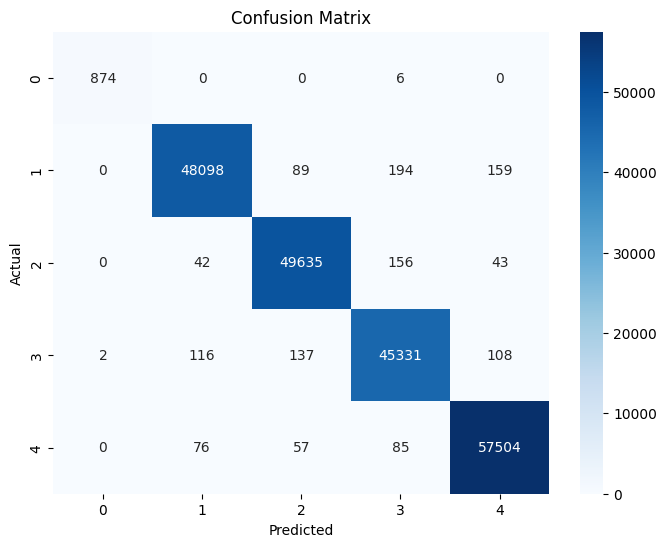

In [92]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [93]:
from sklearn.linear_model import LogisticRegression

In [94]:
lr = LogisticRegression()

In [95]:
lr.fit(X_train, y_train)

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [96]:
y_pred_lr = lr.predict(X_test)

In [107]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
# conf_matrix = confusion_matrix(y_test, y_pred)

In [128]:
classification_lr = classification_report(y_test, y_pred_lr)

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [130]:
print(classification_lr)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       880
           1       0.95      0.96      0.96     48540
           2       0.93      0.94      0.94     49876
           3       0.92      0.92      0.92     45694
           4       0.94      0.94      0.94     57722

    accuracy                           0.94    202712
   macro avg       0.75      0.75      0.75    202712
weighted avg       0.93      0.94      0.94    202712



In [108]:
accuracy_lr

0.9380944394017128

In [99]:
from sklearn.tree import DecisionTreeClassifier

In [100]:
dtc = DecisionTreeClassifier(max_depth = 3, random_state=42)

In [101]:
dtc.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [102]:
y_pred_dtc = dtc.predict(X_test)

In [131]:
classification_dfc = classification_report(y_test, y_pred_dtc)

In [132]:
print(classification_dfc)

              precision    recall  f1-score   support

           0       0.98      0.95      0.97       880
           1       0.63      0.76      0.69     48540
           2       0.80      0.69      0.74     49876
           3       0.73      0.55      0.63     45694
           4       0.74      0.84      0.79     57722

    accuracy                           0.72    202712
   macro avg       0.77      0.76      0.76    202712
weighted avg       0.73      0.72      0.72    202712



In [109]:
accuracy_dfc = accuracy_score(y_test, y_pred_dtc)

In [110]:
accuracy_dfc

0.7182061249457358

In [105]:
from sklearn.neighbors import KNeighborsClassifier

In [106]:
knn_cl = KNeighborsClassifier()

In [112]:
knn_cl.fit(X_train, y_train)

KNeighborsClassifier()

In [113]:
y_pred_knn_cl = knn_cl.predict(X_test)

In [135]:
classification_knn_cl = classification_report(y_test, y_pred_knn_cl)

In [136]:
print(classification_knn_cl)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       880
           1       0.99      0.98      0.98     48540
           2       0.98      0.98      0.98     49876
           3       0.98      0.98      0.98     45694
           4       0.98      0.99      0.98     57722

    accuracy                           0.98    202712
   macro avg       0.98      0.98      0.98    202712
weighted avg       0.98      0.98      0.98    202712



In [114]:
accuracy_knn_cl = accuracy_score(y_test, y_pred_knn_cl)

In [115]:
accuracy_knn_cl

0.9813972532459845

In [116]:
from sklearn.ensemble import RandomForestClassifier

In [117]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42)

In [118]:
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [119]:
y_pred_rfc = rfc.predict(X_test)

In [134]:
classification_rfc = classification_report(y_test, y_pred_rfc)

In [138]:
print(classification_rfc)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       880
           1       1.00      0.99      0.99     48540
           2       0.99      1.00      0.99     49876
           3       0.99      0.99      0.99     45694
           4       0.99      1.00      1.00     57722

    accuracy                           0.99    202712
   macro avg       0.99      0.99      0.99    202712
weighted avg       0.99      0.99      0.99    202712



In [120]:
accuracy_rfc = accuracy_score(y_test, y_pred_rfc)

In [121]:
accuracy_rfc

0.9937349540234421

In [122]:
import xgboost as xgb

In [123]:
xgbc = xgb.XGBClassifier()

In [124]:
xgbc.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [125]:
y_pred_xgbc = xgbc.predict(X_test)

In [139]:
classification_xgbc = classification_report(y_test, y_pred_xgbc)

In [140]:
print(classification_xgbc)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       880
           1       0.99      0.99      0.99     48540
           2       0.99      0.99      0.99     49876
           3       0.99      0.99      0.99     45694
           4       0.99      1.00      1.00     57722

    accuracy                           0.99    202712
   macro avg       0.99      0.99      0.99    202712
weighted avg       0.99      0.99      0.99    202712



In [126]:
accuracy_xgbc = accuracy_score(y_test, y_pred_xgbc)

In [127]:
accuracy_xgbc

0.9934044358498757